In [1]:
import torch

import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.animation as animation

import os, sys
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\KAN_variants")
from ChebyKANLayerCopy import ChebyKAN

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\code")
from myKANODE import KANODE

In [2]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

# alpha, beta, delta, gamma
params = [1.5, 1, 2, 1]
X0 = [0.2, 1.5]

In [3]:
model = ChebyKAN([2, 7, 7, 2], 4)
kanODE = KANODE(model, pred_prey_deriv, X0, params, 20, 6, 0.01)

100%|██████████| 5000/5000 [7:50:41<00:00,  5.65s/it]  


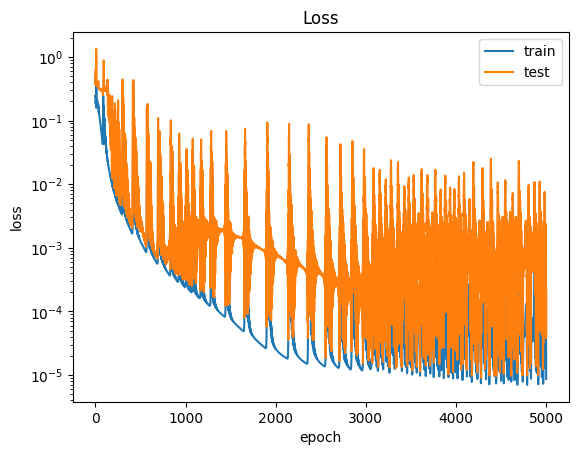

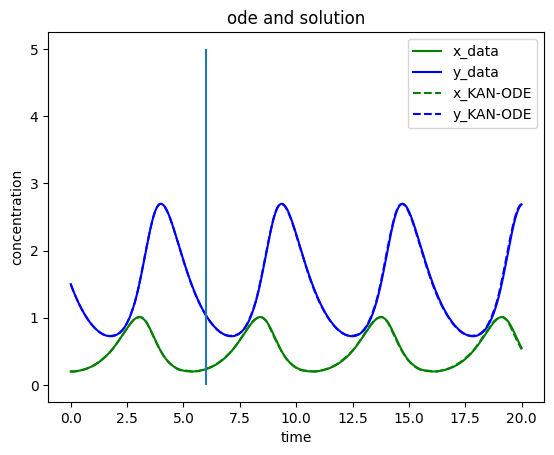

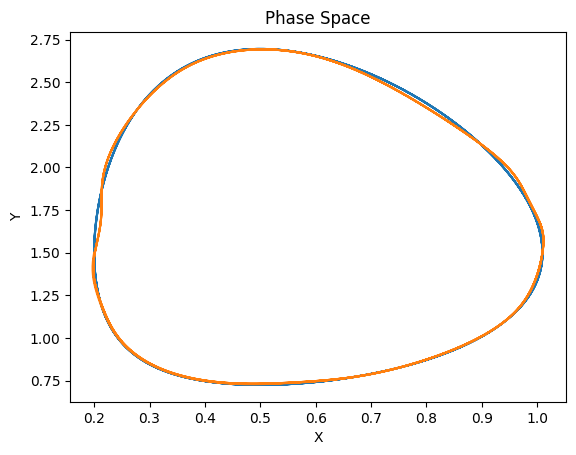

In [4]:
saveDirectory = os.path.join(module_path, "savedModels", "alphaModel5")
if not os.path.isdir(saveDirectory):
    os.makedirs(saveDirectory)

kanODE.train(-1, solverMethod="rk4", saveDirectory=saveDirectory, saveCooldown=200, maxEpochs=5000, evalThreshold = 10**-9)
_, solution = kanODE.test(solverMethod="rk4")
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])

In [5]:
x,y = model.layers[0].plotNeurons()

In [6]:
xp = x[:, 0, 1].detach().numpy()

In [7]:
yp = y[:, 9].detach().numpy()

IndexError: index 9 is out of bounds for dimension 1 with size 7

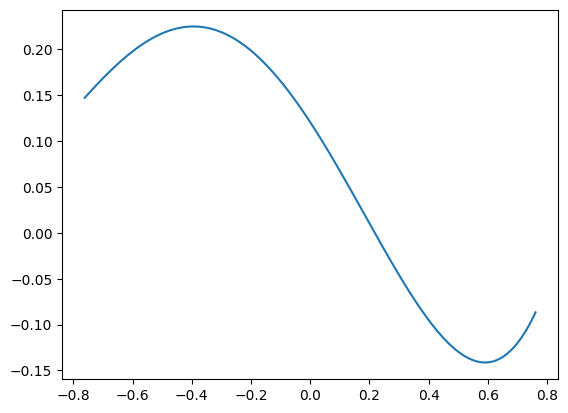

In [ ]:
plt.plot(xp, yp)

In [ ]:
model.layers[0].alpha

Parameter containing:
tensor([0.9659], requires_grad=True)

In [ ]:
kanODE.saveModel(saveDirectory, "finalIteration")